In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from numpy.linalg import svd,eig
import math
bPlot=False
bPlotEig=False
from HeatLearner import HeatLearner
HL = HeatLearner()


In [2]:
from HeatLearner import decompose_field, interp_temp, loadGinterpolants
from HeatLearner import pseudo_inverse_from_svd


In [3]:
HL.digest_fields()

In [15]:
import sys, importlib

if 'bte_1d_boundaryfluxlearn' in sys.modules:
    del sys.modules['bte_1d_boundaryfluxlearn']
from bte_1d_boundaryfluxlearn import buildPropagators
buildPropagators(HL)



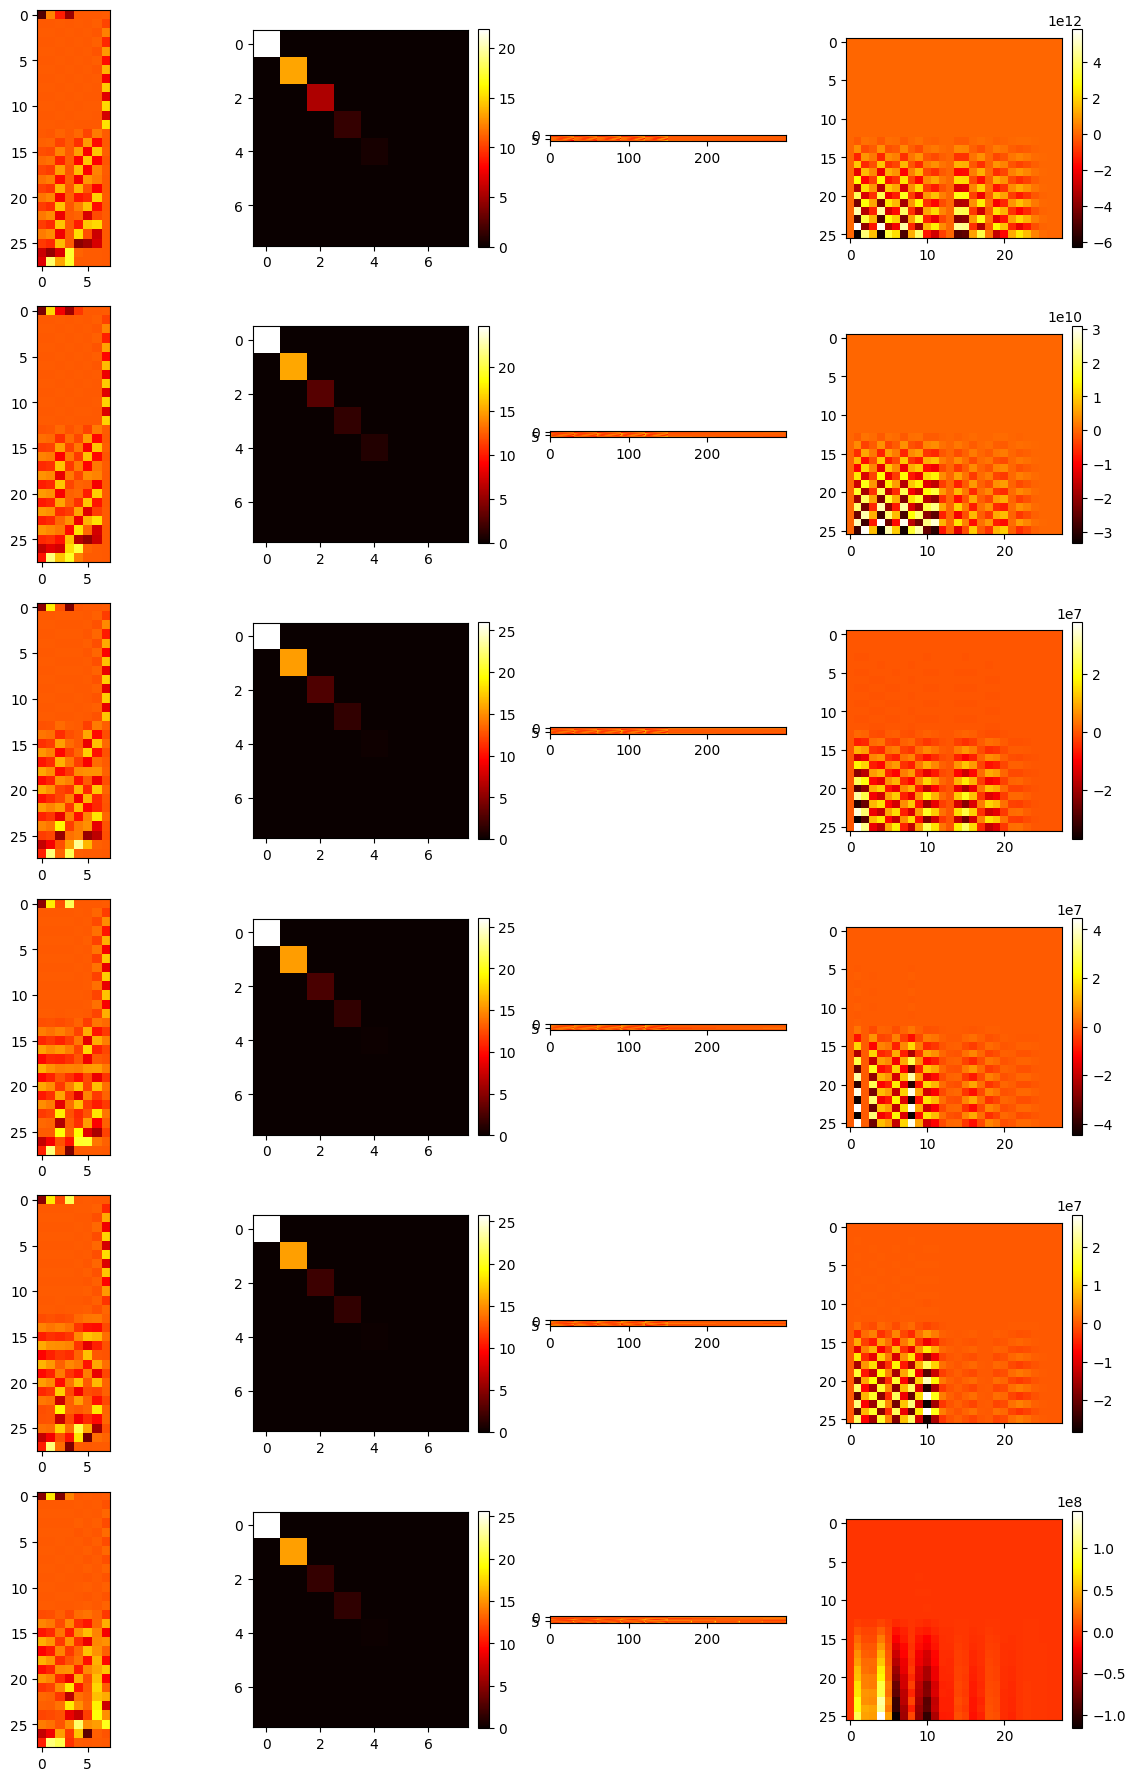

In [5]:
import sys, importlib

if 'bte_1d_boundaryfluxlearn' in sys.modules:
    del sys.modules['bte_1d_boundaryfluxlearn']
from bte_1d_boundaryfluxlearn import nDMD,cDMD

#print(np.array(G))
nA = 6
nM = 4
fig, axs = plt.subplots(nA,nM,figsize=(3*nM,3*nA))
for j,major_stride in enumerate([16]): #Just running with one for now but available for testing
    HL.prop.major_stride = major_stride
    #nA = 13000//major_stride #The quantity of propagators to compute
    lAc = [] #The running list of each propagator, quantity nA
    lTimes = []
    strt = 100
    minor_stride = 1 #not skipping timesteps within prior/posterior observations
    for i,ax in enumerate(axs): #for i in range(nA):
        lX = []
        lY = []
        for j,side in enumerate(HL.sides):
            for k,lev in enumerate(HL.levels):
                variant = f"_{side}{lev:.1f}"
                idx = j  #which index of the boundary flux vector should get assigned the level
                nidx = len(HL.sides)#*ndeg_bv #what is the dimension of the boundary flux vector, only operating with 1 degree (constant)

                npts = 30 #nDMD(i*major_stride)
                cmp = npts #cDMD(i*major_stride)
                #Again using a second order scheme for integrating
                N0 = np.array(HL.dGN[variant][0][strt+i*major_stride  :strt+i*major_stride+npts*minor_stride  :minor_stride]).T
                F0 = np.array(HL.dGF[variant][0][strt+i*major_stride  :strt+i*major_stride+npts*minor_stride  :minor_stride]).T
                B0 = np.zeros( (nidx,npts) );B0[idx,:] = lev
                #print(N0.shape,F0.shape)
                #The priors X, are a composite of two coupled observations [N0;F0], both contributing to the prediction of Y, hence the A matrix has twice the size containing how Y evolves from each group of prior observations
                #Adding to this are the boundary flux levels which should impact the F posteriors
                lX.append( np.concatenate((N0,F0,B0),axis=0) )
                #print(i,X.shape)
                #Here Y is defined as the rate of change of observations. Alternatively could use just an observation of the system, but the physics being studied are nonlinear second order ODE (or nonlinear system of two first order ODE)
                N1 = np.array(HL.dGN[variant][0][strt+i*major_stride+minor_stride:strt+i*major_stride+npts*minor_stride+minor_stride:minor_stride]).T
                F1 = np.array(HL.dGF[variant][0][strt+i*major_stride+minor_stride:strt+i*major_stride+npts*minor_stride+minor_stride:minor_stride]).T
                if True:
                    dN = (N1-N0)/minor_stride
                    dF = (F1-F0)/minor_stride
                else:
                    dN = N1/minor_stride
                    dF = F1/minor_stride
                #The boundary levels don't appear in the Y values because they are priors only, not posteriors
                lY.append( np.concatenate((dN,dF),axis=0) ) #The posteriors Y, are a composite of two coupled difference observations [dN/dt;dF/dt], e.g. the state of Y, hence the A matrix has 4x4 block form containing how Y evolves from each group of prior observations
        #It can be seen that the Y observation is X1-X0 while the X observation is X0. Thus the system behavior being trained is X1-X0 = A(X0). Given X0, the A propagator will yield X1-X0 and then X0. This Y observation is divided by the minor stride timestep to yield a proper first derivative approximate
        X = np.concatenate(lX,axis=1)
        u,s,vt = svd(X,full_matrices=False) #full matrices=false, want to be able to compress, S has nonzero only
        #s += 0.001
        #print(u.shape,s.shape,vt.shape)
        #print(s)
        #A = Y@v.T@np.diag(sinv)@u.T
        if False:
            X_pinv = pseudo_inverse_from_svd(u_100, s, vt_100, cmp) # v.T[:,0:cmp]@np.diag(sinv[0:cmp])@u.T[0:cmp,:]
        else:
            X_pinv = pseudo_inverse_from_svd(u, s, vt, cmp) # v.T[:,0:cmp]@np.diag(sinv[0:cmp])@u.T[0:cmp,:]
        Y = np.concatenate(lY,axis=1)
        Ac = Y@X_pinv #taking the 50% compression, this also seems to stabilise the approximation, maybe consider a study on the variation of this with integration accuracy
        lAc.append(Ac) #this will contain a time evolution of differential propagators
        #lTimes.append(ts[strt+i*major_stride+minor_stride]/2+ts[strt+i*major_stride+npts*minor_stride]/2) #here I'm sampling times at the same rate (major_stride) such that I have time positions aligned with Ac transforms
        lTimes.append(HL.dTS[variant][strt+i*major_stride])#/2+ts[strt+(i+1)*major_stride]/2) #here I'm sampling times at the same rate (major_stride) such that I have time positions aligned with Ac transforms
        #This might not be occuring the way I imagine it. Maybe I should just get the delta_t and increment that in the integration loop
        '''Anorm1 = np.linalg.norm(A[:,0:x_deg],ord=2)
        norm_comm1 = np.linalg.norm(A[:,0:x_deg] @ A[:,0:x_deg].conj().T - A[:,0:x_deg].conj().T @ A[:,0:x_deg], ord=2)
        Anorm0 = np.linalg.norm(A[:,x_deg:2*x_deg],ord=2)
        norm_comm0 = np.linalg.norm(A[:,x_deg:2*x_deg] @ A[:,x_deg:2*x_deg].conj().T - A[:,x_deg:2*x_deg].conj().T @ A[:,x_deg:2*x_deg], ord=2)
        #print(Anorm1,norm_comm1,Anorm0,norm_comm0)
        
        u1 = u[0:x_deg,:]
        u0 = u[x_deg:2*x_deg,:]
        Ardc1 = u1.T@Y@v.T@np.diag(sinv)
        Ardc0 = u0.T@Y@v.T@np.diag(sinv)
        Lam,Xi = eig(Ardc0)
        Lam = np.diag(np.abs(Lam))'''
        A=Ac
        c=8
        if False: #i==0:
            u_100 = u.copy()
            vt_100 = vt.copy()
        #for axi,M in zip(ax,[u[:,0:cmp],np.diag(s[0:cmp]),vt[0:cmp,:],Ac]):#,A,Lam,Xi.real,Xi.imag][:nM]):
        for iax,[axi,M] in enumerate(zip(ax,[u[:,0:c],np.diag(s[0:c]),vt[0:c,:],Ac])):#,A,Lam,Xi.real,Xi.imag][:nM]):
            if iax in [0,2]:
                im = axi.imshow(M, cmap='hot', vmin=-1,vmax=1,
                   origin='upper', interpolation='nearest', aspect='equal')
            else:
                im = axi.imshow(M, cmap='hot', #vmin=-1,vmax=1,
                   origin='upper', interpolation='nearest', aspect='equal')
                fig.colorbar(im, ax=axi, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
if False:
    fig, axs = plt.subplots(nA,1,figsize=(8,12))
    
    print(len(lAc))
    for ax,i in zip(axs, list(range(0,nA))):#len(lAc),100))[:9]):
        im = ax.imshow(lAc[i], cmap='hot', #vmin=-50,vmax=50,
               origin='upper', interpolation='nearest', aspect='equal')
    plt.tight_layout()
    #plt.savefig('matrix_evolution.png')
    plt.show()



In [1]:
import sys, importlib

if 'bte_1d_boundaryfluxlearn' in sys.modules:
    del sys.modules['bte_1d_boundaryfluxlearn']
from bte_1d_boundaryfluxlearn_rev0 import plot_A_elements
plot_A_elements(HL.prop,[ ([0.,0.05],'^'),
                        ([0.05,0.2],'o'),
                        ([0.2,HL.prop.t_list[-1]],'+') ])


NameError: name 'HL' is not defined

In [7]:
import sys, importlib

if 'bte_1d_boundaryfluxlearn' in sys.modules:
    del sys.modules['bte_1d_boundaryfluxlearn']



(13, 1) (13, 1)
(26,)


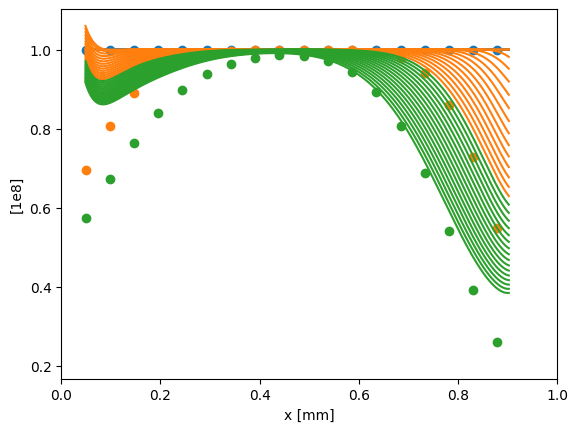

In [33]:
import sys, importlib

if 'bte_1d_boundaryfluxlearn' in sys.modules:
    del sys.modules['bte_1d_boundaryfluxlearn']
from bte_1d_boundaryfluxlearn import integrate
integrate(HL)


In [ ]:
"""        if False: #initial attempt to implement corrector. not sure why I was trying to do it within the epoch when I think by design I won't know Tavg except at epoch boundaries. I was having initial difficulties that I was attributing to integration errors and falsely though correctors were needed already. Final working prototype left the final line (c2+=Hp*(y-Hf)) commented and unused. but this workflow essential shows the chatGPT suggested process of distributing the error back into the coefficients by some operator Hp.
            Hf = np.dot(H.T,c1[Nn,:])
            norm = np.sqrt(np.dot(c1.T,c1)[0,0])
            #print(norm)
            y = (Navg-Navg_0)*(lTimes[i]-t_0)/(t-t_0)+Navg_0
            #print(Hf,y,Hp.shape,c2.shape)
            if False and i%10==0:
                print(c1.T)
            #print(y,Hf,Hp*(y-Hf))
            '''if i==1:
                break'''
            Hp = c1/norm #This seems reasonable in that the magnitude of the current solution vector elements should guide the distribution of the updates. Reasonable as first cut but not rigorous or empirically validated.
            #print(Hp)
            c1+=Hp*(y-Hf)
            #ChatGPT suggests this method under the idea that the vector update should be minimized.
            '''least-squares redistribution of measurement error:

            # Want minimal norm Δc so that H @ (c + Δc) = y_target
            # Δc = H^+ (y_target - H @ c)
            H_vec = H.ravel()   # shape (n_coeffs,)
            residual = (y_target - H_vec.dot(c))
            # pseudo-inverse for H: H^+ = H / (H.H) if H is vector
            Hp = H_vec / (H_vec.dot(H_vec) + 1e-12)
            delta_c = Hp * residual
            c_new = c + delta_c
            I do think this is too simplistic. It may develop oscillitory modes about the average.
            Other suggestions are minimizations of the update with hand tweaking. Another is Mahalanobis-style:
            Weighted (Mahalanobis) minimal-norm correction
            
            If you have prior knowledge of coefficient variances (covariance C), use
            \min \Delta c^T C^{-1} \Delta c\quad\text{s.t. } H\Delta c = r,
            leading to
            \Delta c = C H^T (H C H^T)^{-1} r.
            This will distribute correction across coefficients according to the covariance -- useful if some coefficients are known to be more trustworthy or you want to penalize changing high-frequency coefficients more strongly. An example snippet:
            import numpy as np
            
            # Suppose you have prior coefficient realizations: shape (N, n_c)
            C_samples = np.array([...])  # each row is c^(k)
            
            # Sample covariance
            C = np.cov(C_samples, rowvar=False)
            
            # Regularization with Ledoit–Wolf style that uses lambda to blend diagonal and off-diagonal to improve C condition.
            lam = 1e-6 * np.trace(C) / C.shape[0]
            C_reg = (1 - 0.1) * C + 0.1 * np.diag(np.diag(C)) + lam * np.eye(C.shape[0])
            
            # Then compute correction
            H = ...  # your measurement operator, shape (m, n_c)
            r = ...  # residual vector (y_target - H @ c_pred)
            
            Delta_c = C_reg @ H.T @ np.linalg.inv(H @ C_reg @ H.T) @ r'''
            
        c0=c1 #update c_i solutions
        if False and i%100==0:
            #print(c2.T)
            print(np.dot(H.T,c1[Nn,:]),y)"""
